# CSC_52082_EP : Introduction to Text Mining and NLP

## Lab 5: Tokenization, Perplexity and Decoding strategies



## 1. Tokenization and corpus statistics

We start this lab by taking a look at the tokenization problem and corpus statistics. We will work on the IMDB dataset, a dataset of movie reviews (without taking into account labels).

First of all, we load the dataset:

In [1]:
from datasets import load_dataset

# Load the IMDB dataset (train + test splits)
dataset = load_dataset("stanfordnlp/imdb")

In [2]:
# to speed up, we get a random subset of 5000 documents
sampled = dataset["train"].shuffle(seed=42).select(range(5000))
all_texts = sampled["text"]

#Uncomment only if you want to use all texts. This will slow - a lot - the BPE section.
"""
all_texts = []
for split in ["train", "test"]:
    all_texts.extend(dataset[split]["text"])
"""

'\nall_texts = []\nfor split in ["train", "test"]:\n    all_texts.extend(dataset[split]["text"])\n'

In [3]:
print(f"Number of documents: {len(all_texts)}")
print(f"Example document: {all_texts[0][:200]}...")
print(f"Example document: {all_texts[1][:200]}...")

Number of documents: 5000
Example document: There is no relation at all between Fortier and Profiler but the fact that both are police series about violent crimes. Profiler looks crispy, Fortier looks classic. Profiler plots are quite simple. F...
Example document: This movie is a great. The plot is very true to the book which is a classic written by Mark Twain. The movie starts of with a scene where Hank sings a song with a bunch of kids called "when you stub y...


The following block calculate frequencies and ranks using a simple Counter, and plots the results (logscale).

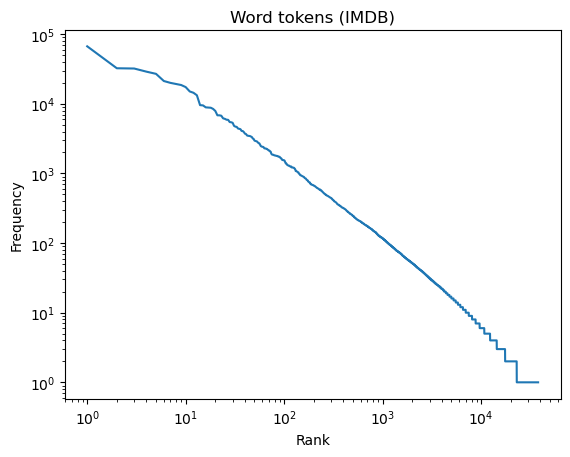

In [4]:
import re
from collections import Counter
import matplotlib.pyplot as plt

def tokenize_words(text):
    #a simple tokenizer based on white spaces and regular expressions
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    return text.split()

# flatten tokens
word_tokens = []
for text in all_texts:
    word_tokens.extend(tokenize_words(text))

# frequency counts
counts = Counter(word_tokens)
freqs = sorted(counts.values(), reverse=True)
ranks = range(1, len(freqs) + 1)

# plot
plt.figure()
plt.loglog(ranks, freqs)
plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.title("Word tokens (IMDB)")
plt.show()

> **Q.1** Is the distribution zipfian? How many tokens have frequency=1?

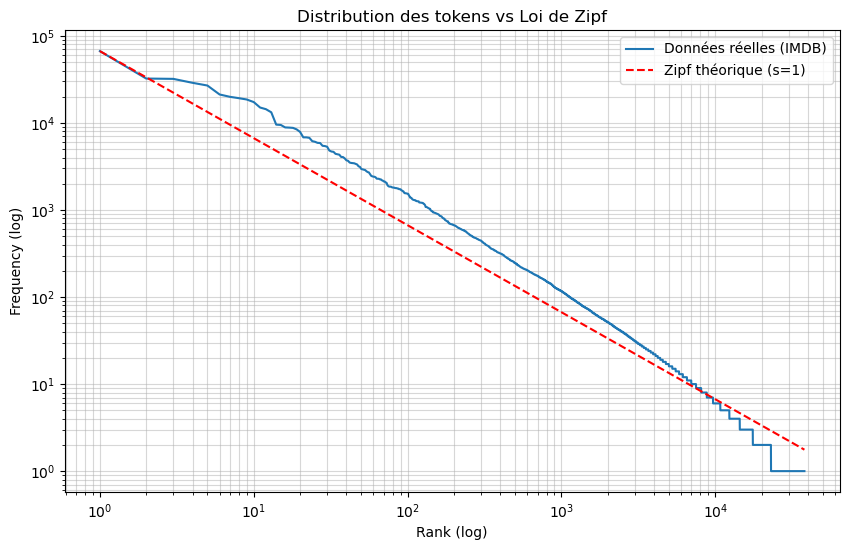

In [5]:
#Answer:

zipf_theoretical = [freqs[0] / r for r in ranks]

# plot
plt.figure(figsize=(10, 6))
plt.loglog(ranks, freqs, label='Données réelles (IMDB)')
plt.loglog(ranks, zipf_theoretical, linestyle='--', color='red', label='Zipf théorique (s=1)')

plt.xlabel("Rank (log)")
plt.ylabel("Frequency (log)")
plt.title("Distribution des tokens vs Loi de Zipf")
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

### 1.1 BPE Tokenization

BPE training begins by extracting a unique word frequency list from a pre-processed corpus and initializing a vocabulary from their constituent characters. The vocabulary is then iteratively expanded by identifying and merging the most frequent adjacent token pairs into new, singular units. This progression moves from character-level pairs to increasingly complex subwords until the target vocabulary size is achieved:

1. Initialization: Build a base vocabulary from all unique symbols found in the normalized text.

2. Identification: Scan the corpus to find the most commonly occurring pair of existing tokens.

3. Expansion: Create a merge rule for that pair, adding the resulting subword to the vocabulary.

4. Iteration: Repeat this process—forming longer strings from shorter ones—until the desired vocabulary limit is met.

> **T.1**: complete the `learn_bpe`function below to implement the BPE algorithm

In [6]:
from collections import defaultdict

def build_vocab(tokens):
    """
    Build the initial BPE vocabulary.

    Input:
        tokens : list of word tokens (e.g. ["this", "movie", "great"])

    Output:
        vocab : Counter mapping "space-separated characters" -> frequency

    Explanation:
        BPE starts from characters, not words.
        Each word is decomposed into characters and we append a special
        end-of-word symbol </w> so merges never cross word boundaries.

        Example:
            "cat" -> "c a t </w>"

        The Counter stores how many times each word occurs in the corpus.
        This lets us weight pair frequencies later.
    """
    vocab = Counter()
    for w in tokens:
        vocab[" ".join(list(w)) + " </w>"] += 1
    return vocab

def get_pairs(vocab):
    """
    Count all adjacent symbol pairs in the current vocabulary.

    Input:
        vocab : dict { "c a t </w>" : 10, ... }

    Output:
        pairs : dict { (symbol1, symbol2) : total_frequency }

    Explanation:
        For every word representation, we look at consecutive symbols:
            "c a t </w>" -> (c,a), (a,t), (t,</w>)

        We accumulate counts weighted by the word frequency.
        The most frequent pair will be merged next.
    """
    pairs = defaultdict(int)
    for word, freq in vocab.items():
        symbols = word.split()
        for i in range(len(symbols) - 1):
            pairs[(symbols[i], symbols[i + 1])] += freq
    return pairs

def merge_pair(pair, vocab):
    """
    Merge the chosen pair everywhere in the vocabulary.

    Input:
        pair  : tuple like ('t', 'h')
        vocab : current vocabulary

    Output:
        new_vocab : updated vocabulary with merged tokens

    Explanation:
        If ('t','h') is frequent, we replace occurrences of
            "t h" -> "th"

        Example:
            "t h e </w>" -> "th e </w>"

        This effectively creates a new subword token.
        We rebuild the vocabulary after the merge.
    """
    bigram = " ".join(pair)
    replacement = "".join(pair)
    new_vocab = {}
    for w in vocab:
        new_word = w.replace(bigram, replacement)
        new_vocab[new_word] = vocab[w]
    return new_vocab

def learn_bpe(tokens, num_merges=500):
    """
    Learn BPE merge rules.

    Input:
        tokens      : list of words from the corpus
        num_merges  : number of merge operations to perform

    Output:
        vocab  : final merged vocabulary
        merges : list of performed merges (the learned BPE rules)

    Algorithm:
        1. Initialize character-level vocabulary
        2. Repeat:
            - count all adjacent pairs
            - find most frequent pair
            - merge it everywhere
        3. Stop after num_merges or if no pairs remain

    """
    vocab = build_vocab(tokens)
    merges = []
    for i in range(num_merges):
        pairs = get_pairs(vocab)
        if not pairs:
            break
        best_pair = max(pairs, key=pairs.get)
        vocab = merge_pair(best_pair, vocab)
        merges.append(best_pair)
    
    return vocab, merges

def extract_bpe_tokens(vocab):
    """
    Convert the merged vocabulary into token frequencies.

    Input:
        vocab : {"th e </w>": 50, ...}

    Output:
        Counter of subword tokens

    Explanation:
        After BPE learning, each word is now represented as subwords.
        We simply count how often each subword appears (weighted by word freq).

        This produces the frequency distribution used for the
        rank/frequency (Zipf) plot.
    """
    bpe_counts = Counter()
    for word, freq in vocab.items():
        for tok in word.split():
            if tok != "</w>":
                bpe_counts[tok] += freq
    return bpe_counts


Now we can run the BPE algorithm on the dataset that we extracted above

In [7]:
# run BPE
vocab_bpe, merges = learn_bpe(word_tokens, num_merges=1000)
bpe_counts = extract_bpe_tokens(vocab_bpe)

# get ranks and frequencies for plot
freqs_bpe = sorted(bpe_counts.values(), reverse=True)
ranks_bpe = range(1, len(freqs_bpe) + 1)

> **T.2** plot the rank/frequency diagram for BPE.

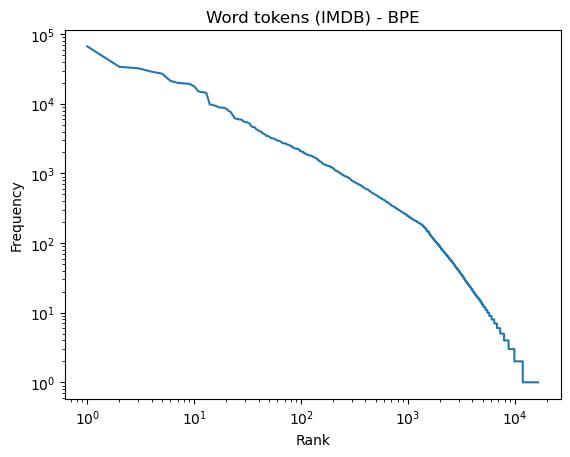

In [8]:
#FILL ME
plt.figure()
plt.loglog(ranks_bpe, freqs_bpe)
plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.title("Word tokens (IMDB) - BPE")
plt.show()


> **Q.2**: How does BPE tokenization modify the Zipf distribution compared to word-level tokenization?

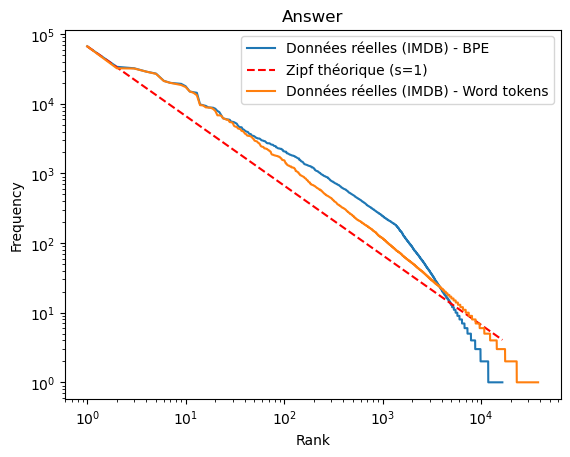

In [9]:

#Answer:
zipf_theoretical = [freqs[0] / r for r in ranks_bpe]


plt.figure()
plt.loglog(ranks_bpe, freqs_bpe, label='Données réelles (IMDB) - BPE')
plt.loglog(ranks_bpe, zipf_theoretical, linestyle='--', color='red', label='Zipf théorique (s=1)')
plt.loglog(ranks, freqs, label='Données réelles (IMDB) - Word tokens')
plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.title("Answer")
plt.legend()
plt.show()

## 2. Perplexity

In this section, we are going to look at perplexity as a way to evaluate the output of the generation of Language Models.

First of all, we will load a simple model (relatively small for performance optimization); we chose `distilgpt2` to start.

In [1]:
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForCausalLM
import math
import matplotlib.pyplot as plt

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)
    
model_name = "distilgpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name).to(device)


cpu
Succès : Le fichier modeling_gpt2 a été chargé correctement.


Now we need to implement the perplexity calculation. Reminder from the course: perplexity is calculated as

$$ PPL = \exp (-\frac{1}{N} \sum_t \log p(x_t | x_{<t}))$$

where $x_t$ is the current token and $t$ represents the position of the token in a sentence of length *N*.

Hint: The inner term of the exponential function corresponds to the cross-entropy loss calculated on the $t$ tokens, so calculating the perplexity is equivalent to calculating:

$$ PPL = \exp(\mathcal{L}oss) $$

> **T.3** : Complete the implementation of perplexity below.

In [ ]:
def perplexity_from_logits(logits, labels):
    """
    Compute perplexity from model logits and target token IDs.

    Perplexity is the exponential of the average cross-entropy loss
    between the model's predicted token distribution and the true
    next tokens.

    Assume a causal language modeling setup:
        - logits at position t predict token at position t+1
        - labels are the input token IDs

    Args:
        logits:
            Tensor of shape (batch_size, sequence_length, vocab_size).
            Raw, unnormalized scores produced by the language model.

        labels:
            Tensor of shape (batch_size, sequence_length).
            Token IDs corresponding to the input sequence.

    Returns:
        A scalar tensor containing the perplexity value.
    """
    
    #FILL ME
    shift_logits = logits[..., :-1, :].contiguous()
    # On retire le premier label (car rien ne le prédit dans cette séquence)
    shift_labels = labels[..., 1:].contiguous()

    # Flatten pour passer à F.cross_entropy : (batch * seq_len, vocab_size)
    loss = F.cross_entropy(
        shift_logits.view(-1, shift_logits.size(-1)), 
        shift_labels.view(-1), 
        reduction='mean'
    )

    # Calcul de la Perplexité : exp(Loss)
    ppl = torch.exp(loss)

    return ppl


In [10]:
def perplexity(model, tokenizer, text):
    """
    Compute the perplexity of a text string under a causal language model.

    The model is evaluated on the same text it is conditioned on,
    which is standard for language model perplexity evaluation.

    Args:
        model:
            A Hugging Face causal language model
            (e.g., GPT-2, DistilGPT-2).

        tokenizer:
            Corresponding tokenizer used to encode the text.

        text:
            Input string whose perplexity will be measured.

    Returns:
        Perplexity score as a Python float.
    """
    enc = tokenizer(text, return_tensors="pt")
    input_ids = enc.input_ids.to(device)

    with torch.no_grad():
        outputs = model(input_ids)
        ppl = perplexity_from_logits(outputs.logits, input_ids)

    return ppl.item()

Now we can test the perplexity on some texts of different styles and types:

In [11]:
texts = {
    "news": "The central bank announced a new policy decision today.",
    "poetry": "The moon drips silver onto the quiet sea.",
    "random": "table banana democracy blue quantum sandwich",
}

for k, v in texts.items():
    print(k, perplexity(model, tokenizer, v))

news 70.42313385009766
poetry 1396.2684326171875
random 127705.921875


You should get a very high perplexity for a random text (this indicates that this text is not likely to be produced by this model)

> **Q.3**: how would you expect the perplexity score to change, on these same examples, if we choose a more powerful/expressive Language Model? (eg - more parameters, trained on more data) Let's assume that these examples are not part of the new model's training data.

In [ ]:
#Answer:



If we switch to a more expressive Language Model (more parameters, larger training corpus), the distribution of probability mass becomes sharper (more "peaked"). The model becomes more confident about what is valid English and more discriminative about what is not.

Here is the expected behavior for each category:
- **News** (Standard Syntax/Semantics): Perplexity $\searrow$ (Decreases)

    Reasoning: A larger model captures syntax, grammar, and common collocations (e.g., "central bank") much better. It assigns a higher probability $p(x_t | x_{<t})$ to these standard sequences.

    Math: Since $p \uparrow$, the loss $-\log(p) \downarrow$, thus $PPL = \exp(loss) \downarrow$.
- **Poetry** (Valid but Rare/Metaphorical): Perplexity $\searrow$ (Decreases)
    Reasoning: Smaller models often treat metaphors ("moon drips silver") as statistical anomalies because they lack semantic depth. A powerful model (LLM) has a better understanding of semantic fields and long-range dependencies, reducing its "surprise" (entropy) on creative but valid English.N

    ote: The drop here is often relatively larger than in the News category, as the model "closes the gap" between literal and figurative understanding.
- **Random** (Word Salad): Perplexity $\nearrow$ (Increases)
    Reasoning: This is counter-intuitive but mathematically logical. A weak model has high uncertainty everywhere; it effectively "smears" probability mass, assigning a small but non-negligible probability to random sequences.A powerful model concentrates almost all its probability mass on the valid token candidates. Consequently, the probability assigned to a random, invalid continuation drops closer to zero ($\epsilon$).
    
    Math: As $p(x_{random}) \to 0$, the term $-\log(p) \to \infty$. The model is "more certain" that this text is nonsense, penalizing it more severely.

Conclusion: The ratio between the perplexity of natural text and random text increases significantly. The model becomes a better discriminator.

## 3. Decoding/Sampling

In this section, we will take a look at different decoding strategies. From the course, we saw that we have various ways to condition the output of the model to be more or less predictable:
1. **Temperature** allows us to modify the probability distribution for the generated tokens
2. **top-k** sampling limits the choice of next token to a fixed *k*
3. **top-p (nucleus)** sampling limits the next token selection to the smallest set of candidates whose cumulative probability mass reaches or exceeds the threshold *p* (candidates are ranked from most to least probable)


> **T.4**: implement the `apply_temperature`, `top_k_filter` and `top_p_filter` functions below

In [12]:
def apply_temperature(logits, temperature):
    """
    Apply temperature scaling to logits before sampling.

    Args:
        logits:
            Tensor of shape (batch_size, vocab_size).
            Raw, unnormalized model scores for the next token.

        temperature:
            Positive float controlling randomness. Must be > 0.

    Returns:
        Tensor of same shape as logits with scaled values.

    Raises:
        ValueError:
            If temperature <= 0.
    """
    if temperature <= 0:
        raise ValueError("temperature must be > 0")
    #FILL ME
    scaled_logits = logits / temperature
    return scaled_logits
    
    
    

In [13]:
def top_k_filter(logits, k):
    """
    Keep only the top-k highest probability tokens and mask the rest.

    All tokens outside the top-k receive -inf so that their probability
    becomes 0 after softmax.

    This restricts sampling to the k most likely tokens, preventing
    extremely unlikely words from being chosen.

    Args:
        logits:
            Tensor of shape (batch_size, vocab_size).

        k:
            Number of tokens to keep. Must be >= 1 and <= vocab_size.

    Returns:
        Tensor of same shape with non-top-k entries set to -inf.
    """
    if k <= 0:
        raise ValueError("k must be >= 1")
    #FILL ME
    top_k_values, _ = torch.topk(logits, k)
    min_top_k = top_k_values[:, -1].unsqueeze(1)
    filtered_logits = torch.where(logits < min_top_k, torch.full_like(logits, float('-inf')), logits)
    return filtered_logits
    


In [30]:
def top_p_filter(logits, p):
    """
    Apply nucleus (top-p) filtering to logits.

    Instead of keeping a fixed number of tokens (top-k), this keeps the
    smallest set of tokens whose cumulative probability mass >= p.

    Often produces more natural text than top-k.

    Args:
        logits:
            Tensor of shape (batch_size, vocab_size).

        p:
            Cumulative probability threshold in (0, 1].
            Typical values: 0.8–0.95.

    Returns:
        Tensor with tokens outside the nucleus set to -inf.

    """
    if not (0 < p <= 1):
        raise ValueError("p must be in (0, 1]")
        
    #FILL ME
    sorted_logits, sorted_indices = torch.sort(logits, descending=True, dim=-1)
    sorted_probs = F.softmax(sorted_logits, dim=-1)
    cumulative_probs = torch.cumsum(sorted_probs, dim=-1)
    sorted_indices_to_remove = cumulative_probs > p
    sorted_indices_to_remove[..., 1:] = sorted_indices_to_remove[..., :-1].clone()
    sorted_indices_to_remove[..., 0] = False
    indices_to_remove = torch.zeros_like(logits, dtype=torch.bool)
    # On disperse (scatter) les booléens 'True' aux bons endroits originaux
    indices_to_remove.scatter_(dim=1, index=sorted_indices, src=sorted_indices_to_remove) 
    filtered_logits = logits.clone() 
    filtered_logits[indices_to_remove] = float('-inf')    
    return filtered_logits
    
    


In [31]:
def sample_token(logits):
    """
    Sample a token index from a categorical distribution defined by logits.

    Steps:
        1. Convert logits into probabilities using softmax
        2. Draw a multinomial sample

    Args:
        logits:
            Tensor of shape (batch_size, vocab_size).

    Returns:
        Tensor of shape (batch_size, 1) containing sampled token indices.

    Example:
        next_token = sample_token(logits)
    """
    probs = torch.softmax(logits, dim=-1)
    return torch.multinomial(probs, num_samples=1)


In [32]:
def generate(
    prompt,
    max_tokens=50,
    temperature=1.0,
    top_k=None,
    top_p=None
):
    input_ids = tokenizer(prompt, return_tensors="pt").input_ids.to(device)

    for _ in range(max_tokens):
        with torch.no_grad():
            outputs = model(input_ids)
            logits = outputs.logits[:, -1, :]

        logits = apply_temperature(logits, temperature)

        if top_k is not None:
            logits = top_k_filter(logits, top_k)

        if top_p is not None:
            logits = top_p_filter(logits, top_p)

        next_token = sample_token(logits)
        input_ids = torch.cat([input_ids, next_token], dim=1)

    return (tokenizer.decode(input_ids[0], skip_special_tokens=True)).strip() #strip to remove trailing <eos>


Now, let's see some examples of results for different decoding strategies:

In [33]:
prompt = "The future of artificial intelligence is"

print("Greedy (temp=0.1)")
print(generate(prompt, temperature=0.1))
print()

print("Temperature 1.0")
print(generate(prompt, temperature=1.0))
print()

print("Top-k = 50")
print(generate(prompt, temperature=1.0, top_k=50))
print()

print("Top-p = 0.9")
print(generate(prompt, temperature=1.0, top_p=0.9))


Greedy (temp=0.1)
The future of artificial intelligence is not yet clear.

Temperature 1.0
The future of artificial intelligence is coming out.Image: concept artBaltemorse collection
Pancestrians taking their limousine and taking turns peeing in the streets of London on April 10th. The first R.E.O., The Blair Roundtable,

Top-k = 50
The future of artificial intelligence is also in its early stages — that could take a few years for systems to work. On Tuesday, researchers at the Electronic Frontier Foundation outlined how they plan to use quantum computing to build a single device, which would enable artificial intelligence to work independently on everything

Top-p = 0.9
The future of artificial intelligence is the question of which will it live, not whether it will ever be as automated or as ingenious as its predecessors.


### 3.1 Perplexity of generated text

> **T.5**: Calculate the perplexity of generated text from the prompt above with the following parameters:
- a. low temperature (0.3)
- b. standard temperature, top_k=40
- c. standard temperature, top_p=0.9
- d. high temperature (2.0)

Verify what is the effect on different decoding strategies and temperature parameters on the perplexity of the text.
Suggestion: print sample type, perplexity and generated text.

In [34]:
#answer:
prompts = {
    "low temperature": generate(prompt, temperature=0.3),
    "standard temperature": generate(prompt, temperature=1.0, top_k=40),
    "standard temperature + top-p": generate(prompt, temperature=1.0, top_p=0.9),
    "high temperature": generate(prompt, temperature=2.0),
}

# calculate perplexity for each generated text
for desc, text in prompts.items():
    ppl = perplexity(model, tokenizer, text)
    print(f"{desc} (perplexity: {ppl:.2f}):\n{text}\n")


low temperature (perplexity: 90.80):
The future of artificial intelligence is still in the works.





 contents Effects of artificial intelligence on human behavior are still very complex.

standard temperature (perplexity: 12.19):
The future of artificial intelligence is already on the verge of becoming one of the biggest fields in the future", she said.




"However, in the past couple of years we have seen the emergence of artificial intelligence.
"We are now able to make a

standard temperature + top-p (perplexity: 20.60):
The future of artificial intelligence is too new for everybody!Today, we have an update on a major series of reforms to the Office of the Director of National Intelligence (NI) that undermine the NSA's surveillance capabilities. This includes the Justice Department's appointment of Secretary of State John

high temperature (perplexity: 93180.27):
The future of artificial intelligence is fructose two baking button slides aka hijab AMViewgRay } archaeological ligi

### 3.2 Output token Distribution Visualization

We can inspect the probabilities for the next token given the above prompt:

In [35]:
def plot_distribution(prompt, temperature=1.0):
    input_ids = tokenizer(prompt, return_tensors="pt").input_ids.to(device)
    with torch.no_grad():
        logits = model(input_ids).logits[:, -1, :]

    logits = apply_temperature(logits, temperature)
    probs = torch.softmax(logits, dim=-1)[0]

    top_probs, top_ids = torch.topk(probs, 10)
    tokens = tokenizer.convert_ids_to_tokens(top_ids)

    plt.bar(tokens, top_probs.cpu())
    plt.title(f"Temperature = {temperature}")
    plt.show()


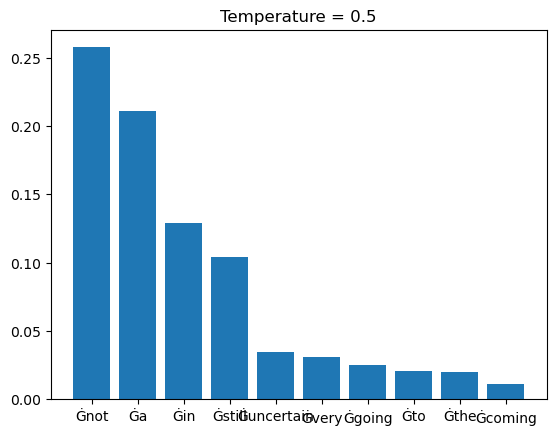

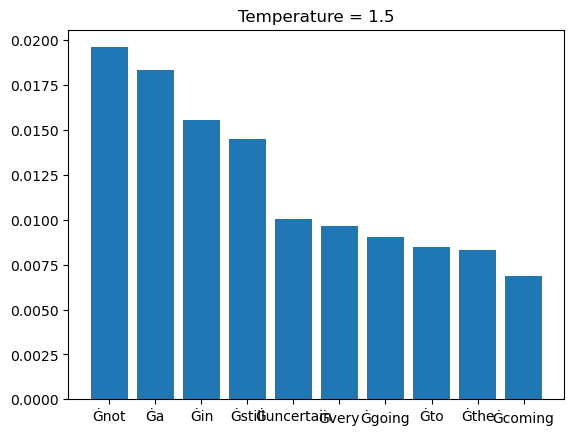

In [36]:
plot_distribution(prompt, temperature=0.5)
plot_distribution(prompt, temperature=1.5)


> **T.6**: you may test different prompts and temperature settings to verify the effects of temperature on generation

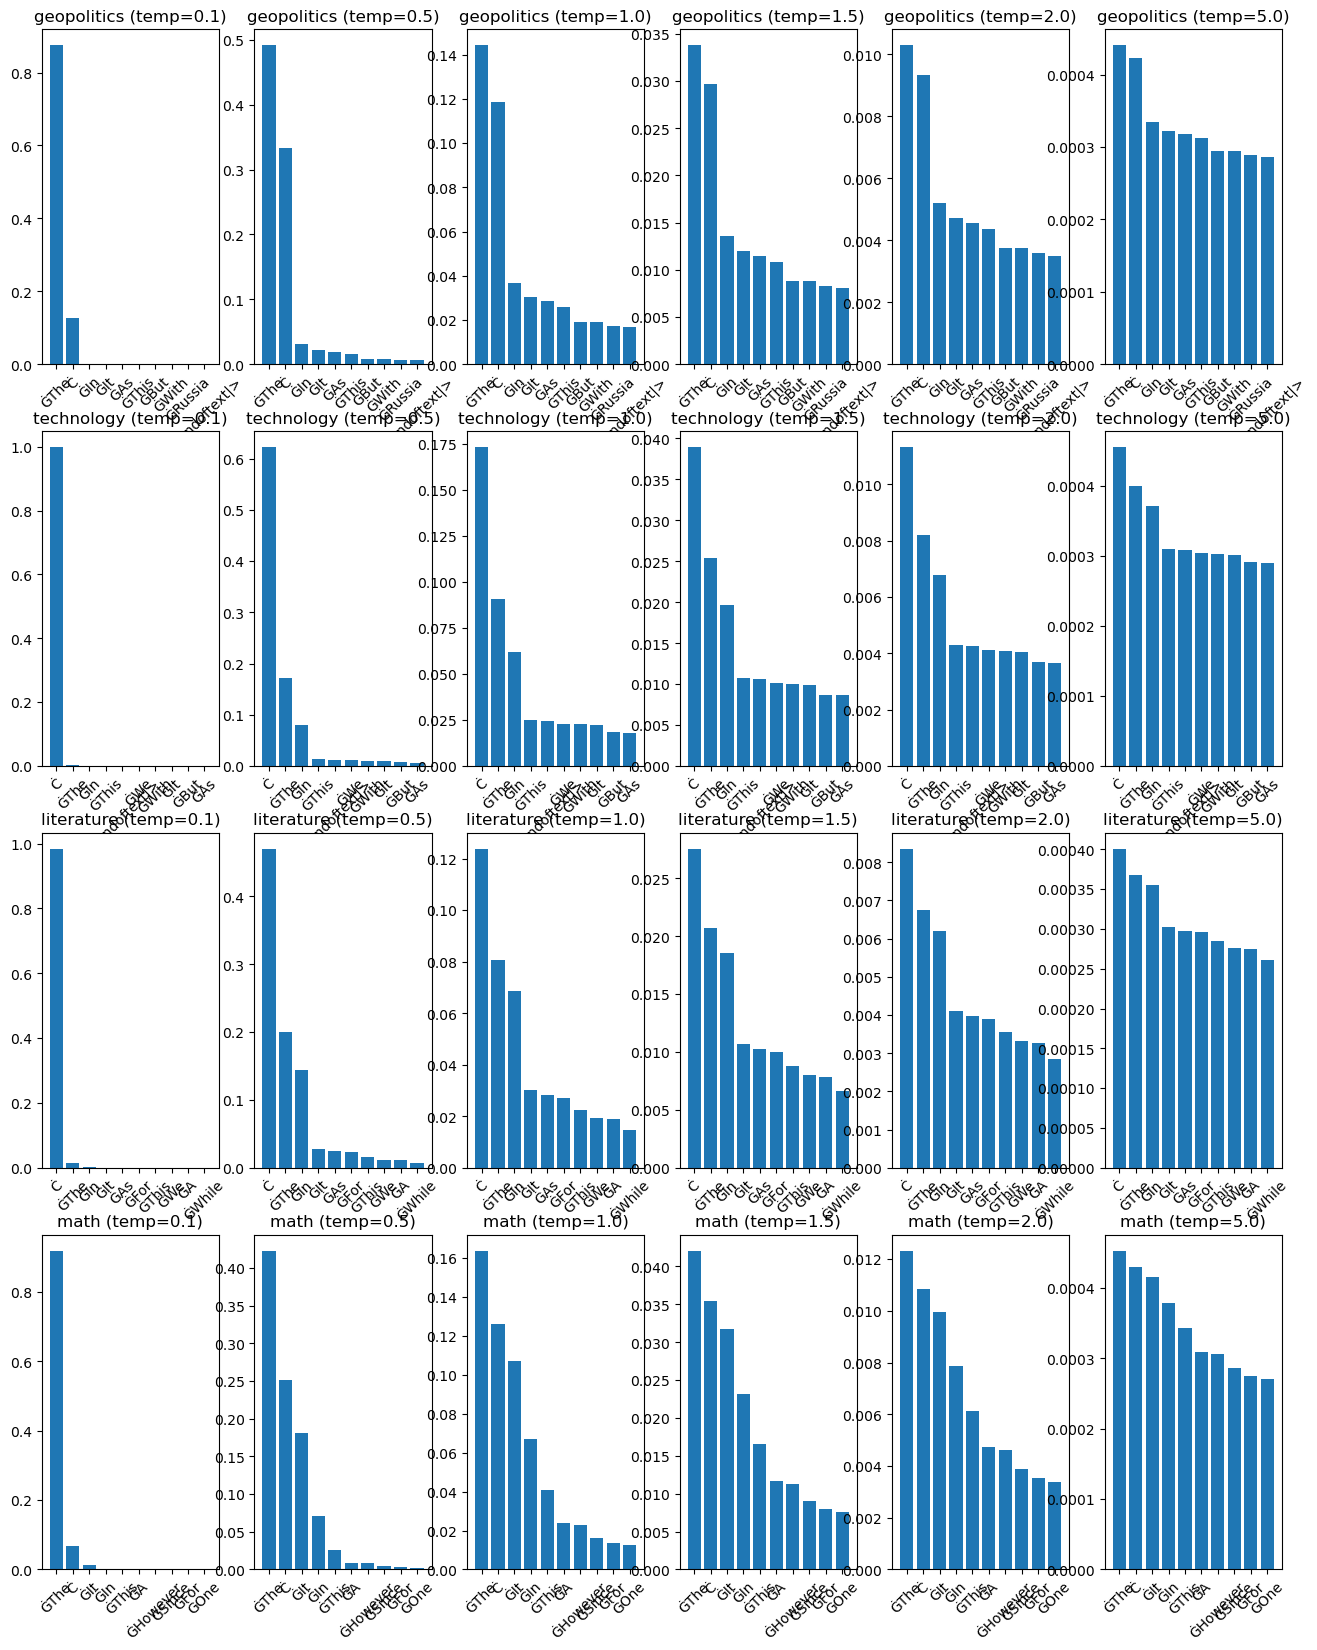

In [43]:
prompts = {
    "geopolitics": "The geopolitical landscape is rapidly changing with the rise of new powers.",
    "technology": "The latest advancements in quantum computing have the potential to revolutionize the industry.",
    "literature": "In the realm of literature, the interplay between narrative and character development is crucial for crafting compelling stories.",
    "math": "The Riemann Hypothesis is one of the most famous unsolved problems in mathematics, concerning the distribution of prime numbers."
}

temp_settings = [0.1, 0.5, 1.0, 1.5, 2.0, 5.0]

# plot a unique figure to the impact of temperature on different prompts to see effects of temperature on different prompts
plt.figure(figsize=(16, 20))
for i, (desc, prompt) in enumerate(prompts.items()):
    input_ids = tokenizer(prompt, return_tensors="pt").input_ids.to(device)
    with torch.no_grad():
        logits = model(input_ids).logits[:, -1, :]

    for temp in temp_settings:
        scaled_logits = apply_temperature(logits, temp)
        probs = torch.softmax(scaled_logits, dim=-1)[0]
        top_probs, top_ids = torch.topk(probs, 10)
        tokens = tokenizer.convert_ids_to_tokens(top_ids)

        plt.subplot(len(prompts), len(temp_settings), i * len(temp_settings) + temp_settings.index(temp) + 1)
        plt.bar(tokens, top_probs.cpu())
        plt.title(f"{desc} (temp={temp})")
        plt.xticks(rotation=45)

